In [2]:
import sqlite3
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [3]:
DATA_DIR = Path("../data/raw")

df_p = pd.read_csv(DATA_DIR / "patient.csv")
df_t = pd.read_csv(DATA_DIR / "treatment.csv")
df_v = pd.read_csv(DATA_DIR / "vitalPeriodic.csv")
df_h = pd.read_csv(DATA_DIR / "hospital.csv")
df_d = pd.read_csv(DATA_DIR / "diagnosis.csv")

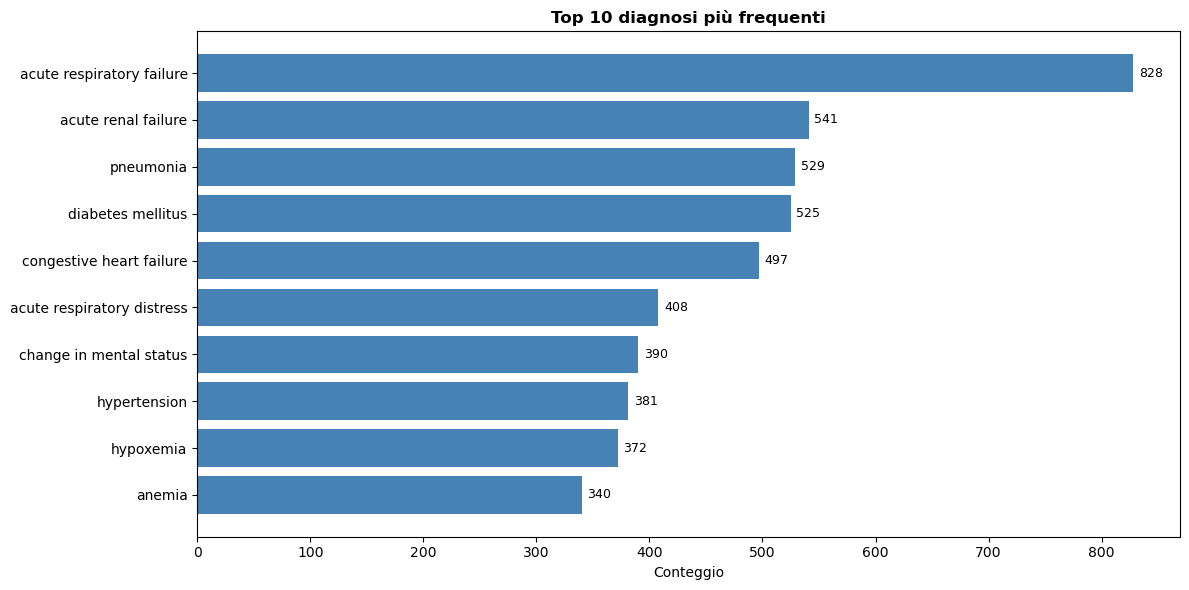

In [3]:
top10 = df_d["diagnosisstring"].value_counts().head(10)

# Abbrevia le etichette
labels = [d.split("|")[-1] for d in top10.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(labels, top10.values, color="steelblue")

for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

ax.set_xlabel("Conteggio")
ax.set_title("Top 10 diagnosi più frequenti", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [4]:
pazienti_arf = df_d[df_d["diagnosisstring"] == 
                    "pulmonary|respiratory failure|acute respiratory failure"
                    ]["patientunitstayid"].unique()

print(f"Pazienti con ARF: {len(pazienti_arf)}")

# Join con trattamenti
trattamenti_arf = df_t[df_t["patientunitstayid"].isin(pazienti_arf)]

print(f"Trattamenti totali: {len(trattamenti_arf)}")
print("\nTop 20 trattamenti:")
print(trattamenti_arf["treatmentstring"].value_counts().head(20))

Pazienti con ARF: 226
Trattamenti totali: 10041

Top 20 trattamenti:
treatmentstring
pulmonary|ventilation and oxygenation|mechanical ventilation                                             476
pulmonary|radiologic procedures / bronchoscopy|chest x-ray                                               217
infectious diseases|medications|therapeutic antibacterials                                               142
pulmonary|consultations|Pulmonary/CCM consultation                                                       131
gastrointestinal|medications|stress ulcer prophylaxis|famotidine                                         122
cardiovascular|intravenous fluid|normal saline administration                                            118
pulmonary|ventilation and oxygenation|oxygen therapy (40% to 60%)                                        116
cardiovascular|vascular disorders|VTE prophylaxis|compression stockings                                  112
pulmonary|medications|bronchodilator       

In [5]:
pazienti_arf1 = df_d[df_d["diagnosisstring"] == 
                    "renal|disorder of kidney|acute renal failure"
                    ]["patientunitstayid"].unique()

print(f"Pazienti con arf1: {len(pazienti_arf1)}")

# Join con trattamenti
trattamenti_arf1 = df_t[df_t["patientunitstayid"].isin(pazienti_arf1)]

print(f"Trattamenti totali: {len(trattamenti_arf1)}")
print("\nTop 20 trattamenti:")
print(trattamenti_arf1["treatmentstring"].value_counts().head(20))

Pazienti con arf1: 186
Trattamenti totali: 5714

Top 20 trattamenti:
treatmentstring
pulmonary|ventilation and oxygenation|mechanical ventilation                                      247
pulmonary|radiologic procedures / bronchoscopy|chest x-ray                                        126
infectious diseases|medications|therapeutic antibacterials                                        100
endocrine|glucose metabolism|insulin                                                               99
pulmonary|medications|bronchodilator                                                               94
pulmonary|consultations|Pulmonary/CCM consultation                                                 85
gastrointestinal|medications|stress ulcer prophylaxis|pantoprazole                                 80
cardiovascular|vascular disorders|VTE prophylaxis|compression stockings                            73
cardiovascular|shock|vasopressors|norepinephrine > 0.1 micrograms/kg/min                           

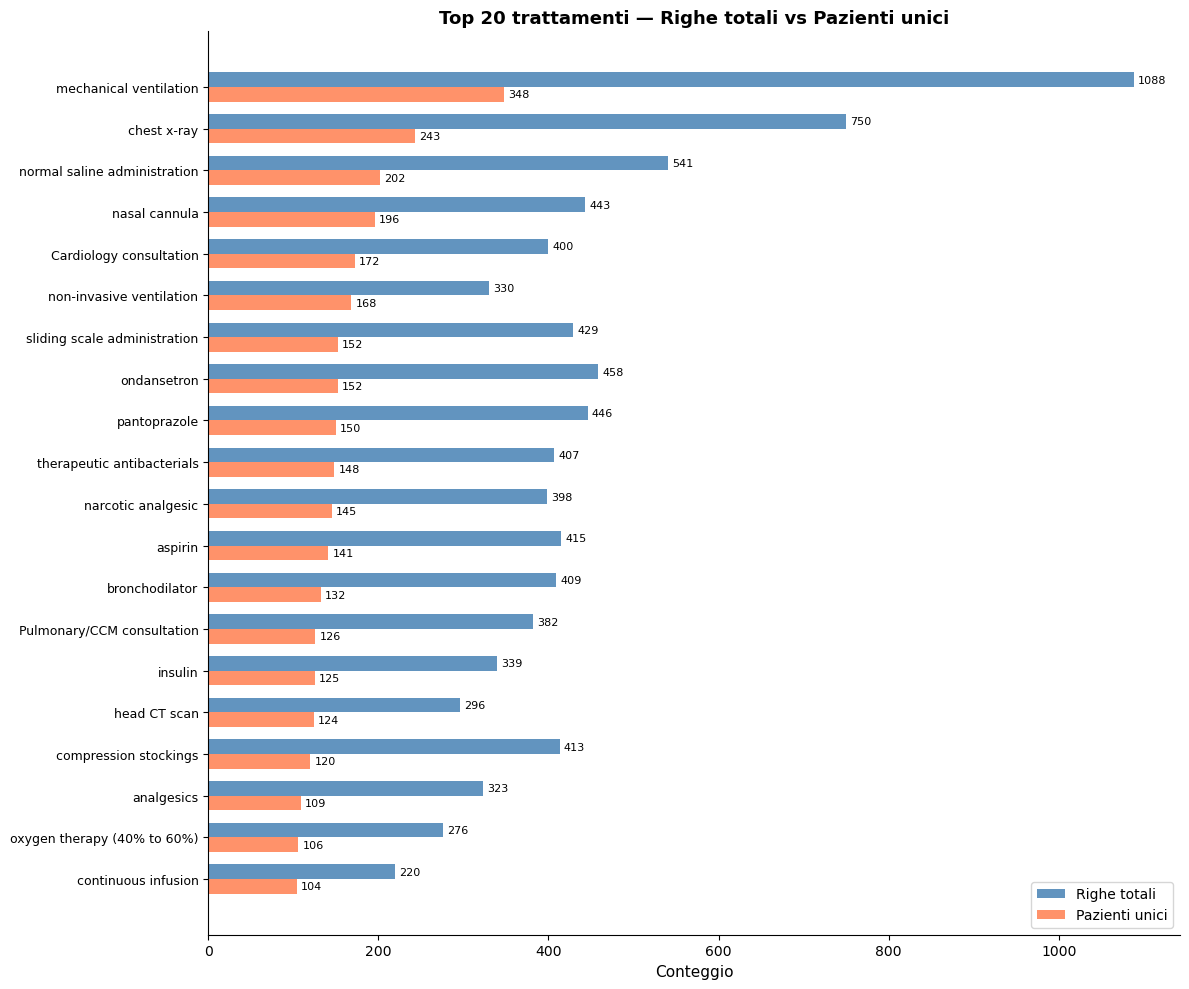

In [6]:
df_counts = pd.DataFrame({
    'righe_totali': df_t['treatmentstring'].value_counts(),
    'pazienti_unici': df_t.groupby('treatmentstring')['patientunitstayid'].nunique()
}).sort_values('pazienti_unici', ascending=True).tail(20)  # top 20

# Accorcia le label (prendi solo l'ultimo livello della gerarchia)
df_counts.index = df_counts.index.str.split('|').str[-1]

fig, ax = plt.subplots(figsize=(12, 10))

y = range(len(df_counts))
height = 0.35

bars1 = ax.barh(
    [i + height/2 for i in y],   #posizione delle barre
    df_counts['righe_totali'],
    height=height,
    label='Righe totali',
    color='steelblue',
    alpha=0.85
)
bars2 = ax.barh(
    [i - height/2 for i in y],
    df_counts['pazienti_unici'],
    height=height,
    label='Pazienti unici',
    color='coral',
    alpha=0.85
)

# Etichette valori
for bar in bars1:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,   #posizione testo centrato e a destra del wigdht
            f'{int(bar.get_width())}', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=8)

ax.set_yticks(list(y))
ax.set_yticklabels(df_counts.index, fontsize=9)
ax.set_xlabel('Conteggio', fontsize=11)
ax.set_title('Top 20 trattamenti — Righe totali vs Pazienti unici', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
# Calcola metriche per ospedale
hospital_stats = df_p.groupby('hospitalid').agg(
    stay_totali=('patientunitstayid', 'count'),
    pazienti_unici=('uniquepid', 'nunique'),
    tasso_mortalita=('hospitaldischargestatus', lambda x: (x == 'Expired').mean())
).round(3).reset_index()

# Unisci con le info ospedaliere
hospital_stats = hospital_stats.merge(
    df_h[['hospitalid', 'numbedscategory', 'teachingstatus', 'region']],
    on='hospitalid',
    how='left'
)

# Ordina per stay totali
hospital_stats = hospital_stats.sort_values('stay_totali', ascending=False)

print(f"Ospedali totali: {len(hospital_stats)}")
print(f"Tasso mortalità medio: {hospital_stats['tasso_mortalita'].mean():.3f}")
print()
print(hospital_stats.to_string(index=False))




Ospedali totali: 186
Tasso mortalità medio: 0.088

 hospitalid  stay_totali  pazienti_unici  tasso_mortalita numbedscategory teachingstatus    region
        146           40              10            0.050       250 - 499              f      West
        123           30              10            0.067       100 - 249              f     South
        171           25              10            0.120       100 - 249              f      West
        157           25              10            0.280       250 - 499              f      West
        167           24              10            0.000          >= 500              t      West
        155           24              10            0.083       100 - 249              f      West
        154           23              10            0.043       250 - 499              f      West
        310           22              10            0.091       100 - 249              f   Midwest
        243           22              10            0.045 

In [8]:
morti = df_p["unitdischargestatus"].value_counts()
print(morti)

# Percentuale
print(f"\nMorti: {(df_p['unitdischargestatus'] == 'Expired').sum()}")
print(f"Totale pazienti: {len(df_p)}")
print(f"Mortalità: {(df_p['unitdischargestatus'] == 'Expired').mean()*100:.1f}%")

unitdischargestatus
Alive      2392
Expired     126
Name: count, dtype: int64

Morti: 126
Totale pazienti: 2520
Mortalità: 5.0%


In [9]:
# Crea colonna ventilato
ventilati = df_t[df_t["treatmentstring"].str.contains(
    "mechanical ventilation", case=False, na=False
)]["patientunitstayid"].unique()

df_p["ventilato"] = df_p["patientunitstayid"].isin(ventilati).astype(int)

# Distribuzione morti per gruppo
dist = df_p.groupby("ventilato")["unitdischargestatus"].value_counts()
print(dist)

# Mortalità % per gruppo
print("\nMortalità per gruppo:")
print(df_p.groupby("ventilato")["unitdischargestatus"]
      .apply(lambda x: (x == "Expired").mean() * 100)
      .rename({0: "Non ventilati", 1: "Ventilati"}))

ventilato  unitdischargestatus
0          Alive                  2017
           Expired                  65
1          Alive                   375
           Expired                  61
Name: count, dtype: int64

Mortalità per gruppo:
ventilato
Non ventilati     3.119002
Ventilati        13.990826
Name: unitdischargestatus, dtype: float64


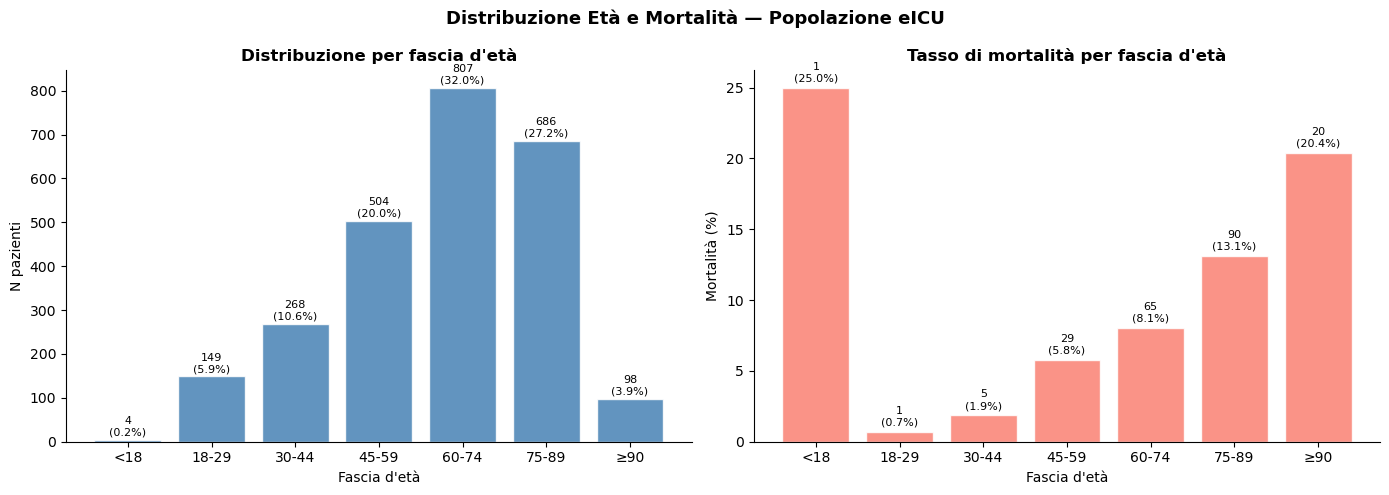

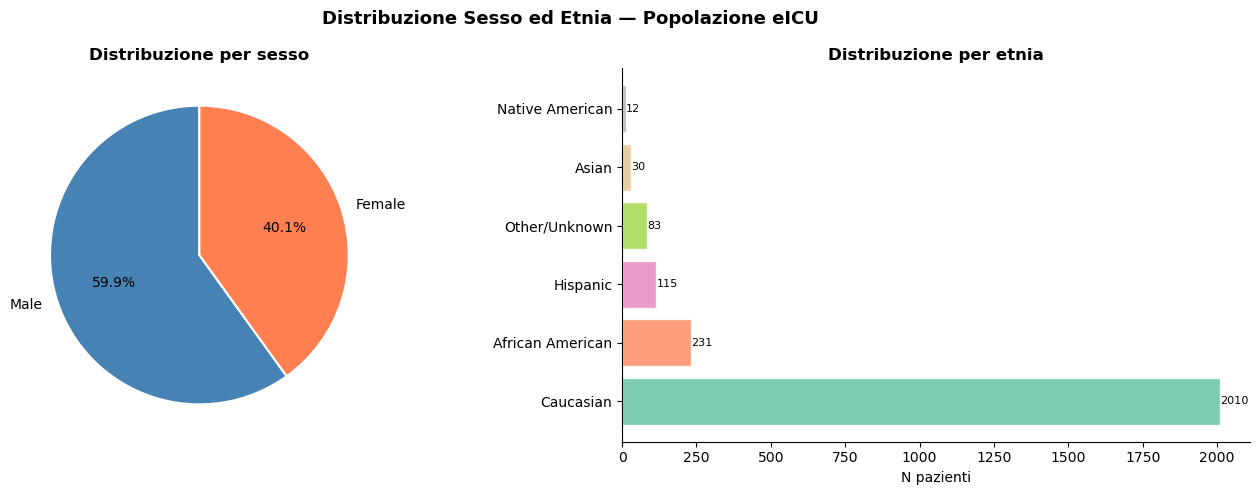

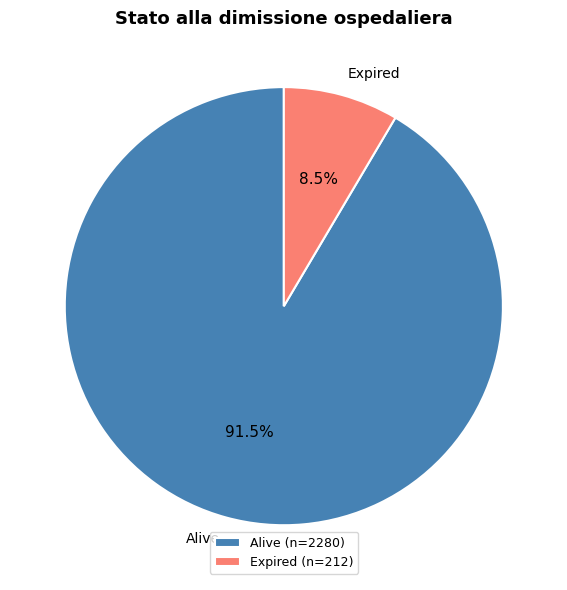

Età media: 63.3 anni
Età mediana: 66.0 anni

Tasso mortalità ospedaliera: 8.41%

--- SESSO ---
gender
Male      1508
Female    1008
Name: count, dtype: int64

--- ETNIA ---
ethnicity
Caucasian           2010
African American     231
Hispanic             115
Other/Unknown         83
Asian                 30
Native American       12
Name: count, dtype: int64


In [13]:
# Pulizia età
df_p['age_clean'] = pd.to_numeric(df_p['age'], errors='coerce')
df_p.loc[df_p['age'] == '> 89', 'age_clean'] = 90

# Fasce età
bins = [0, 18, 30, 45, 60, 75, 90, 120]
labels = ['<18', '18-29', '30-44', '45-59', '60-74', '75-89', '≥90']
df_p['fascia_eta'] = pd.cut(df_p['age_clean'], bins=bins, labels=labels, right=False)
df_p['deceduto'] = (df_p['hospitaldischargestatus'] == 'Expired').astype(int)

# ============================================================
# FIGURA 1 — Età e Mortalità per fascia
# ============================================================
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle('Distribuzione Età e Mortalità — Popolazione eICU',
              fontsize=13, fontweight='bold')

# Grafico 1a — Distribuzione età con n e percentuale
counts = df_p['fascia_eta'].value_counts().sort_index()
totale = len(df_p)

bars = axes1[0].bar(counts.index, counts.values, color='steelblue',
                    alpha=0.85, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes1[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                  f'{int(val)}\n({val/totale*100:.1f}%)',
                  ha='center', va='bottom', fontsize=8)
axes1[0].set_title("Distribuzione per fascia d'età", fontweight='bold')
axes1[0].set_xlabel("Fascia d'età")
axes1[0].set_ylabel('N pazienti')
axes1[0].spines['top'].set_visible(False)
axes1[0].spines['right'].set_visible(False)

# Grafico 1b — Mortalità per fascia età (n morti + % sulla fascia)
mortalita_eta = df_p.groupby('fascia_eta', observed=True)['deceduto'].agg(['sum', 'mean'])

bars4 = axes1[1].bar(mortalita_eta.index, mortalita_eta['mean'] * 100,
                     color='salmon', alpha=0.85, edgecolor='white')
for bar, (n_morti, perc) in zip(bars4, zip(mortalita_eta['sum'], mortalita_eta['mean'] * 100)):
    axes1[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                  f'{int(n_morti)}\n({perc:.1f}%)',
                  ha='center', va='bottom', fontsize=8)
axes1[1].set_title("Tasso di mortalità per fascia d'età", fontweight='bold')
axes1[1].set_xlabel("Fascia d'età")
axes1[1].set_ylabel('Mortalità (%)')
axes1[1].spines['top'].set_visible(False)
axes1[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eta_mortalita.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 2 — Sesso ed Etnia
# ============================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Distribuzione Sesso ed Etnia — Popolazione eICU',
              fontsize=13, fontweight='bold')

# Grafico 2a — Torta sesso
sesso = df_p['gender'].value_counts()
colori = ['steelblue', 'coral', 'lightgray']
wedges, texts, autotexts = axes2[0].pie(
    sesso.values, labels=sesso.index, autopct='%1.1f%%',
    colors=colori[:len(sesso)], startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in autotexts:
    text.set_fontsize(10)
axes2[0].set_title('Distribuzione per sesso', fontweight='bold')

# Grafico 2b — Etnia
etnia = df_p['ethnicity'].value_counts()
colors_etnia = plt.cm.Set2(np.linspace(0, 1, len(etnia)))
bars3 = axes2[1].barh(etnia.index, etnia.values,
                      color=colors_etnia, alpha=0.85, edgecolor='white')
for bar in bars3:
    axes2[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                  str(int(bar.get_width())), va='center', fontsize=8)
axes2[1].set_title('Distribuzione per etnia', fontweight='bold')
axes2[1].set_xlabel('N pazienti')
axes2[1].spines['top'].set_visible(False)
axes2[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('sesso_etnia.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURA 3 — Torta mortalità
# ============================================================
fig3, ax = plt.subplots(figsize=(6, 6))

stato = df_p['hospitaldischargestatus'].value_counts()
colori = ['steelblue', 'salmon', 'lightgray']
wedges, texts, autotexts = ax.pie(
    stato.values,
    labels=stato.index,
    autopct='%1.1f%%',
    colors=colori[:len(stato)],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for text in autotexts:
    text.set_fontsize(11)

ax.set_title('Stato alla dimissione ospedaliera', fontweight='bold', fontsize=13)
labels_leg = [f"{idx} (n={val})" for idx, val in zip(stato.index, stato.values)]
ax.legend(wedges, labels_leg, loc="lower center", fontsize=9)

plt.tight_layout()
plt.savefig('mortalita_torta.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# STATISTICHE TESTUALI
# ============================================================
print(f"Età media: {df_p['age_clean'].mean():.1f} anni")
print(f"Età mediana: {df_p['age_clean'].median():.1f} anni")
print(f"\nTasso mortalità ospedaliera: {df_p['deceduto'].mean()*100:.2f}%")
print("\n--- SESSO ---")
print(df_p['gender'].value_counts())
print("\n--- ETNIA ---")
print(df_p['ethnicity'].value_counts())

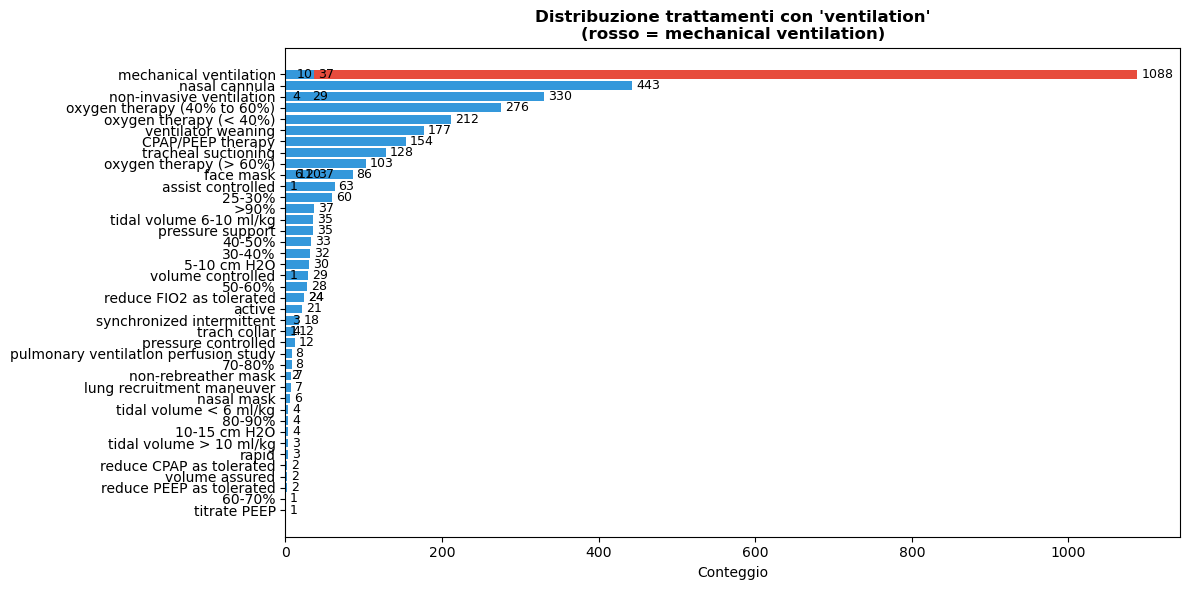

In [14]:
#confrontre la distribuzione fra i vari trattamenti "ventilation"

# Filtra tutti i trattamenti che contengono "ventilation"
ventilation_treatments = df_t[df_t["treatmentstring"].str.contains("ventilation", case=False, na=False)]

# Conta le occorrenze
counts = ventilation_treatments["treatmentstring"].value_counts()

# Separa il principale dagli altri
main = "pulmonary|ventilation and oxygenation|mechanical ventilation"
main_count = counts.get(main, 0)
others = counts.drop(main, errors="ignore")

# Combina per il plot
plot_data = pd.concat([pd.Series({main: main_count}), others])

# Abbrevia le etichette per leggibilità
labels = [t.split("|")[-1] if "|" in t else t for t in plot_data.index]

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#e74c3c"] + ["#3498db"] * len(others)
bars = ax.barh(labels, plot_data.values, color=colors)

# Aggiungi i valori sulle barre
for bar, val in zip(bars, plot_data.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)

ax.set_xlabel("Conteggio")
ax.set_title("Distribuzione trattamenti con 'ventilation'\n(rosso = mechanical ventilation)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()



In [12]:
mask = df_t["treatmentstring"].str.contains("ventilation", case=False, na=False)
total = mask.sum()
print(f"Trattamenti con ventilazione: {total}")

#unici per pazienti
total_pazienti = df_t[mask]["patientunitstayid"].nunique()
print(f"Pazienti con ventilazione: {total_pazienti}")



Trattamenti con ventilazione: 3718
Pazienti con ventilazione: 826


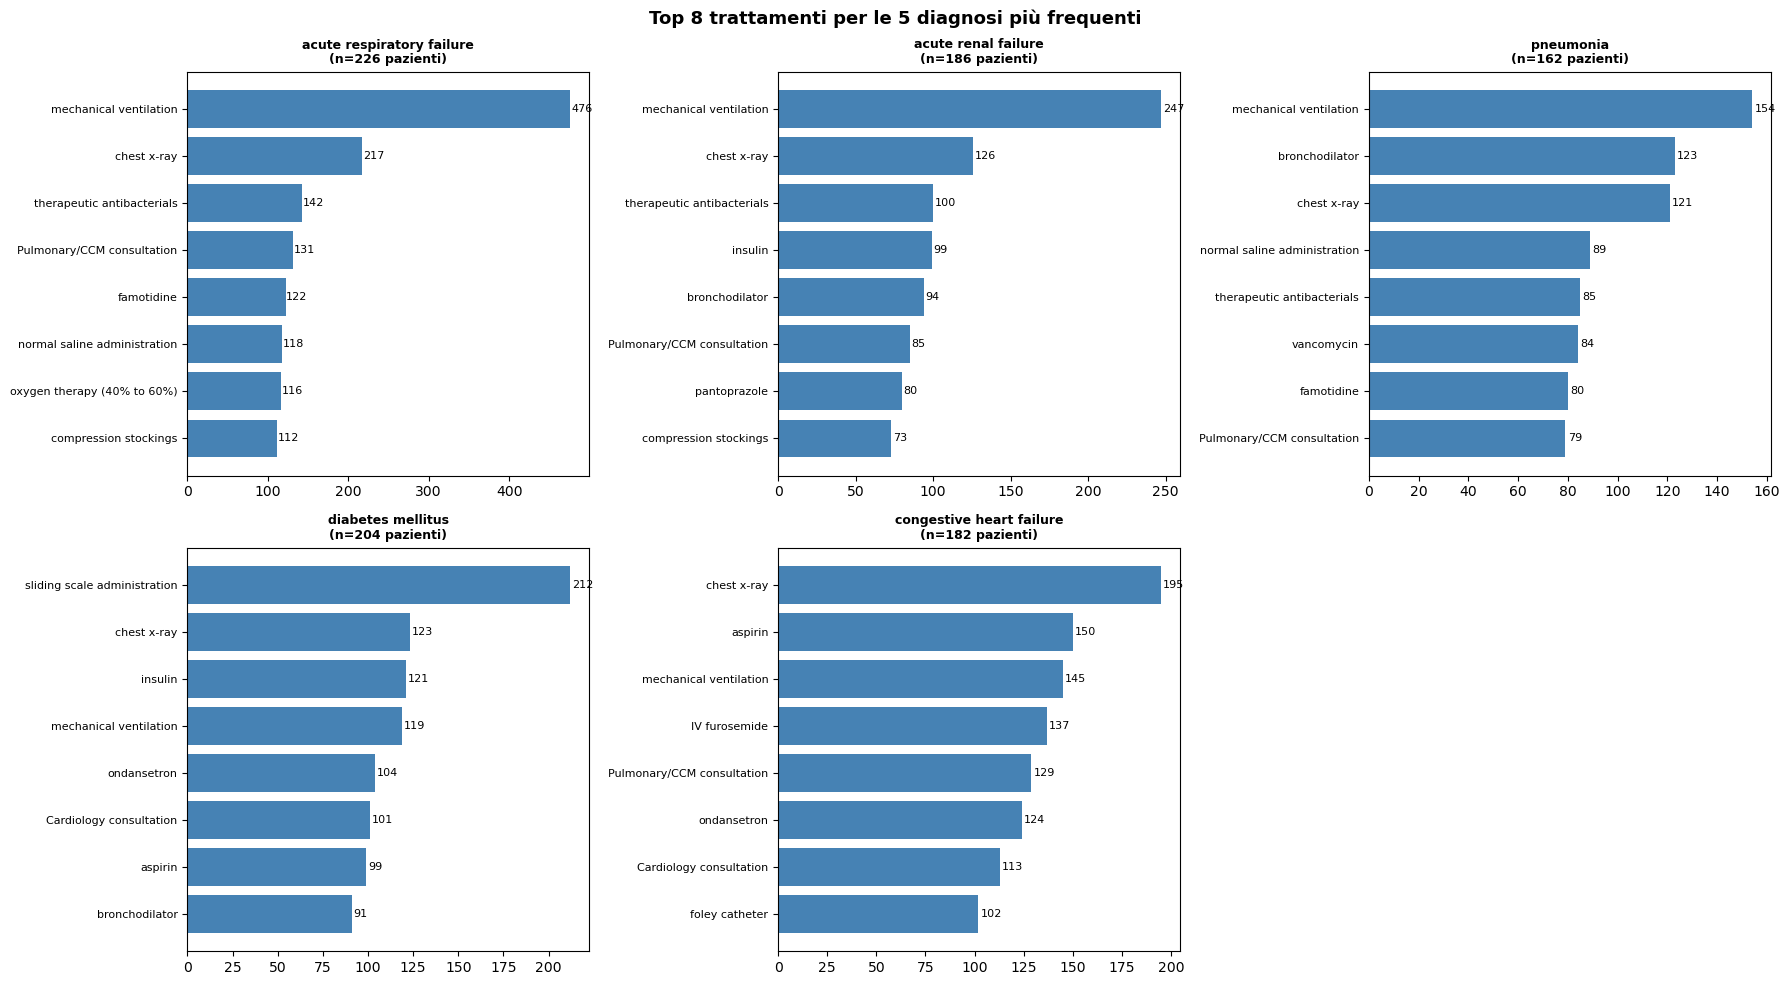

In [15]:
top5_diagnosi = df_d["diagnosisstring"].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, diagnosi in enumerate(top5_diagnosi):
    pazienti = df_d[df_d["diagnosisstring"] == diagnosi]["patientunitstayid"].unique()
    trattamenti = df_t[df_t["patientunitstayid"].isin(pazienti)]["treatmentstring"].value_counts().head(8)
    
    # Abbrevia etichette
    labels = [t.split("|")[-1] for t in trattamenti.index]
    label_diagnosi = diagnosi.split("|")[-1]
    
    ax = axes[i]
    bars = ax.barh(labels, trattamenti.values, color="steelblue")
    
    for bar, val in zip(bars, trattamenti.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=8)
    
    ax.set_title(f"{label_diagnosi}\n(n={len(pazienti)} pazienti)", 
                 fontweight="bold", fontsize=9)
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=8)

# Nascondi subplot vuoto
axes[-1].set_visible(False)

fig.suptitle("Top 8 trattamenti per le 5 diagnosi più frequenti", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
DATA_DIR = Path("../data/raw")
df_p = pd.read_csv(DATA_DIR / "patient.csv")
df_t = pd.read_csv(DATA_DIR / "treatment.csv")

# Definisci trattamento A
ventilati = df_t[
    df_t["treatmentstring"].str.contains("mechanical ventilation", case=False, na=False) &
    (df_t["treatmentoffset"] <= 1440)
]["patientunitstayid"].unique()

df_p["A"] = df_p["patientunitstayid"].isin(ventilati).astype(int)
df_p["Y"] = (df_p["unitdischargestatus"] == "Expired").astype(int)

df_analytical = df_p.copy()

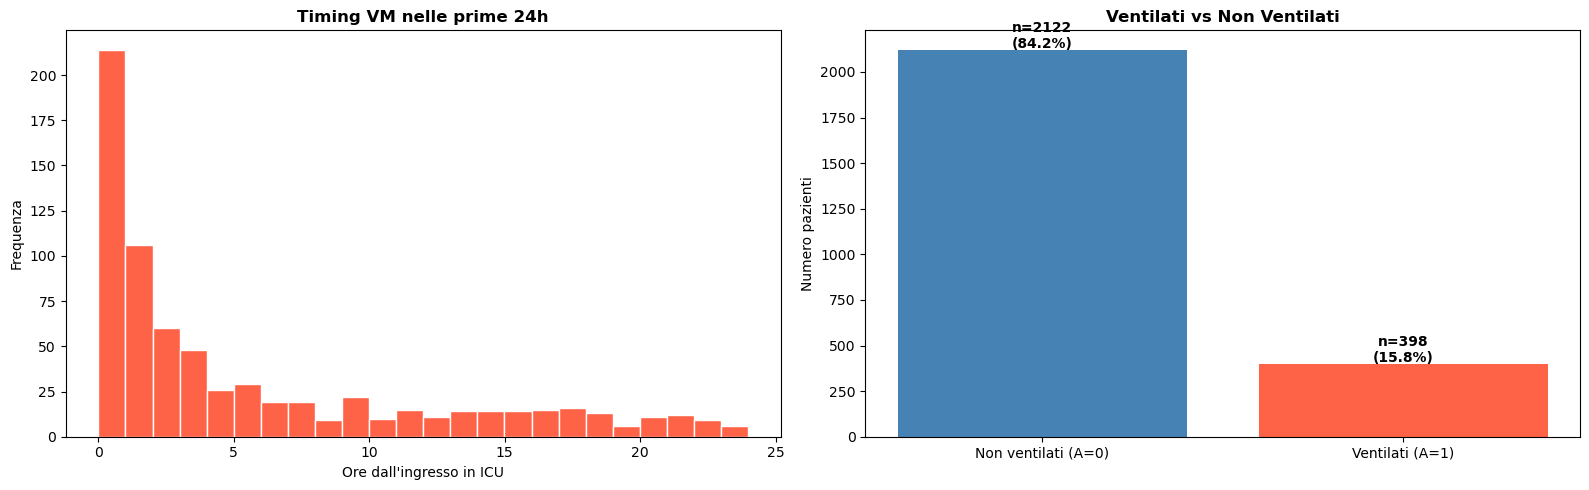

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Timing VM nelle prime 24h
vm_times = df_t[
    df_t["treatmentstring"].str.contains("mechanical ventilation", case=False, na=False) &
    (df_t["treatmentoffset"].between(0, 1440))
]["treatmentoffset"] / 60

axes[0].hist(vm_times, bins=24, color="tomato", edgecolor="white")
axes[0].set_xlabel("Ore dall'ingresso in ICU")
axes[0].set_ylabel("Frequenza")
axes[0].set_title("Timing VM nelle prime 24h", fontweight="bold")

# 2. Ventilati vs Non ventilati
gruppi = df_p["A"].value_counts()
bars = axes[1].bar(["Non ventilati (A=0)", "Ventilati (A=1)"],
                   gruppi.values, color=["steelblue", "tomato"])
for bar, val in zip(bars, gruppi.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f"n={val}\n({val/len(df_p)*100:.1f}%)",
                 ha="center", fontweight="bold")
axes[1].set_ylabel("Numero pazienti")
axes[1].set_title("Ventilati vs Non Ventilati", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_ventilazione.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
missing = df_p.isnull().sum()
missing_pct = df_p.isnull().mean() * 100

missing_df = pd.DataFrame({
    'n_missing': missing,
    'pct_missing': missing_pct
}).sort_values('pct_missing', ascending=False)

print(missing_df[missing_df['n_missing'] > 0])

                           n_missing  pct_missing
dischargeweight                 1284    50.952381
hospitaladmitsource              594    23.571429
apacheadmissiondx                299    11.865079
admissionweight                  198     7.857143
admissionheight                   69     2.738095
ethnicity                         39     1.547619
hospitaldischargelocation         32     1.269841
hospitaldischargestatus           28     1.111111
unitadmitsource                   22     0.873016
age_clean                          4     0.158730
unitdischargelocation              4     0.158730
fascia_eta                         4     0.158730
age                                4     0.158730
gender                             4     0.158730
unitdischargestatus                2     0.079365


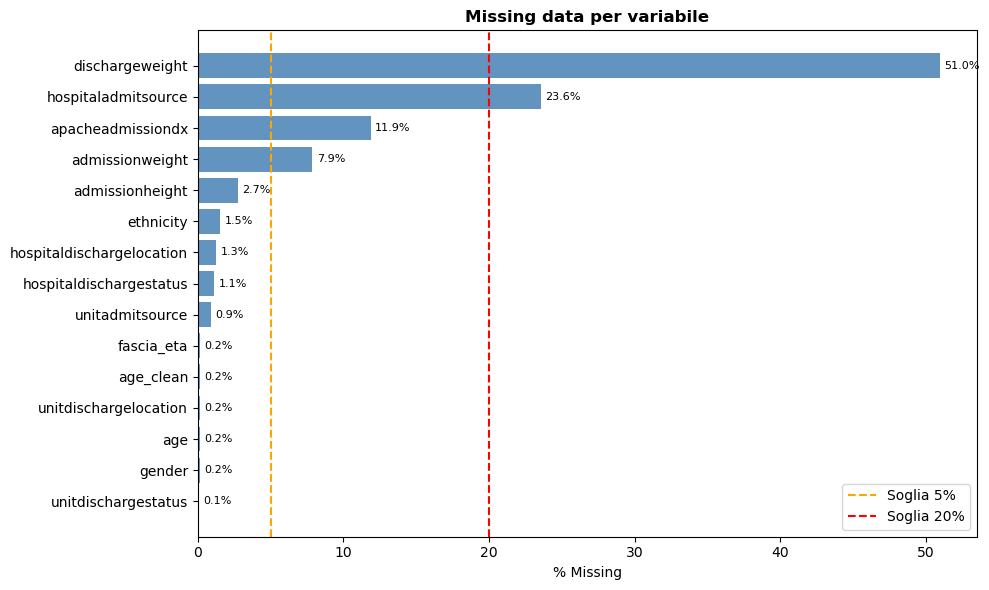

In [17]:
import matplotlib.pyplot as plt

# Solo variabili con almeno 1 missing
missing_plot = missing_pct[missing_pct > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(missing_plot.index, missing_plot.values, color="steelblue", alpha=0.85)

for bar, val in zip(bars, missing_plot.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.axvline(5, color='orange', linestyle='--', label='Soglia 5%')
ax.axvline(20, color='red', linestyle='--', label='Soglia 20%')
ax.set_xlabel('% Missing')
ax.set_title('Missing data per variabile', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Test semplice: i pazienti con missing sono diversi da quelli senza?
var = "admissionweight"

print(f"Età media CON {var}:    {df_p[df_p[var].notna()]['age_clean'].mean():.1f}")
print(f"Età media SENZA {var}: {df_p[df_p[var].isna()]['age_clean'].mean():.1f}")

print(f"\nMortalità CON {var}:    {df_p[df_p[var].notna()]['deceduto'].mean()*100:.1f}%")
print(f"Mortalità SENZA {var}: {df_p[df_p[var].isna()]['deceduto'].mean()*100:.1f}%")

Età media CON admissionweight:    63.2
Età media SENZA admissionweight: 64.4

Mortalità CON admissionweight:    8.3%
Mortalità SENZA admissionweight: 9.6%
